In [1]:
# AMATH 581 HW 5
# Jonathan McCormack 
import numpy as np
from scipy.integrate import solve_ivp
import time
import copy
import matplotlib.pyplot as plt

#-----------------------
# Exercise 1: Solve the Reaction - Diffusion with Fast Fourier Transform
#-----------------------

# Set the initial conditions
L = 20 # Length of Spatial Domain
n = 64 # Number of internal points
tspan = [0, 4]
dt = 0.5
t_eval = np.arange(tspan[0], tspan[1] + dt, dt)
B = 1
D1 = D2 = 0.1
m = 1 # Number of spirals

# Set Spatial Mesh Grid
x = np.linspace(-L/2, L/2, n+1)[0:-1]
y = x.copy()
X, Y = np.meshgrid(x, y)

# Set Spectral Mesh Grid
#kx = 2*np.pi*np.fft.fftfreq(n, d=L/n)
r1=np.arange(0,n/2,1)
r2=np.arange(-n/2,0,1)
kx = (2*np.pi/L)*np.concatenate((r1,r2))
kx[0] = 1e-6
ky = kx.copy()
KX, KY = np.meshgrid(kx, ky)
K = KX**2 + KY**2
Kvec = K.reshape(n**2, order='F')

# Set Initial Conditions for u and v
uhat0=np.fft.fft2(np.tanh(np.sqrt(X**2+Y**2))*np.cos(m*np.angle(X+1j*Y)-(np.sqrt(X**2+Y**2))))
vhat0=np.fft.fft2(np.tanh(np.sqrt(X**2+Y**2))*np.sin(m*np.angle(X+1j*Y)-(np.sqrt(X**2+Y**2))))

uhat0vec = (uhat0).reshape(n**2, order = 'F')
vhat0vec = (vhat0).reshape(n**2, order = 'F')

initvec = np.concatenate((uhat0vec, vhat0vec))

# Define FFT Solution Equation
def fftrhs(t, initvec, Kvec, KX, KY, B, D1, D2, m, n):

    uhat = initvec[0:n**2].reshape(n, n, order = 'F')
    vhat = initvec[n**2:].reshape(n, n, order = 'F')
    u = np.real(np.fft.ifft2(uhat))
    v = np.real(np.fft.ifft2(vhat))
    
    A_2 = u**2 + v**2 #A^2 = u^2 + v^2
    lambda_A = 1 - A_2 #lambda = 1 - A^2
    omega_A = -B * A_2 #omega = -B * A^2

    uhatt_nlin = np.fft.fft2(lambda_A*u - omega_A*v)
    #uhatt_nlinvec = uhatt_nlin.reshape(n**2 , order = 'F')
    
    vhatt_nlin = np.fft.fft2(omega_A*u + lambda_A*v)
    #vhatt_nlinvec = vhatt_nlin.reshape(n**2 , order = 'F')

    uhatt = -D1*(KX**2 + KY**2)*uhat + uhatt_nlin # Change to u with respect to time in Spectral Domain
    vhatt = -D2*(KX**2 + KY**2)*vhat + vhatt_nlin # Change to v with respect to time in Spectral Domain

    uhatt_vec = uhatt.reshape(n**2, order = 'F')
    vhatt_vec = vhatt.reshape(n**2, order = 'F')
    
    rhs = np.concatenate((uhatt_vec, vhatt_vec))
    return rhs

# Execute FFT Solution
tic = time.time()
sol = solve_ivp(fftrhs, (t_eval[0], t_eval[-1]), initvec, t_eval = t_eval, args = [Kvec, KX, KY, B, D1, D2, m, n])
toc = time.time()
print(toc-tic)

# Store real and imaginary results 
A1 = copy.deepcopy(np.real(sol.y.T))
print(np.shape(A1))

A2 = copy.deepcopy(np.imag(sol.y.T))
print(np.shape(A2))

del L, n, tspan, dt, B, D1, D2, m, t_eval, x, y, X, Y, kx, ky, KX, KY, K, Kvec, uhat0, vhat0, uhat0vec, vhat0vec, initvec, tic, toc

0.07027697563171387
(9, 8192)
(9, 8192)


In [2]:

#-----------------------
# Exercise 2: Solve the Reaction - Diffusion with Discrete Chebyshev Transform
#-----------------------

# Define Chevyshev Matrix function
def cheb(N):
    if N == 0:
        return np.array([[0.]]), np.array([1.])
    x = np.cos(np.pi * np.arange(0, N+1) / N).reshape(-1,1)
    c = np.hstack(([2.], np.ones(N-1), [2.])) * ((-1) ** np.arange(0, N+1))
    X = np.tile(x, (1,N+1))
    dX = X - X.T
    C = c.reshape(-1, 1) @ (1.0 / c).reshape(1, -1)
    D = C / (dX + np.eye(N + 1))
    D = D - np.diag(np.sum(D, axis=1))
    return D, x.flatten()

# Set the initial conditions
L = 20 # Length of Spatial Domain
n = 30 # Number of internal points
tspan = [0, 4]
dt = 0.5
t_eval = np.arange(tspan[0], tspan[1] + dt, dt)
B = 1
D1 = D2 = 0.1
m = 1 # Number of spirals

# Set Chebyshev Matrix
D, x = cheb(n)
D_1 = D*2/L # rescaled for [-L, L]
x = x*L/2 # rescaled for [-L, L]
D_2 = D_1 @ D_1
D_2[0, :] = 0
D_2[-1, :] = 0

# Set Spatial Mesh Grid
y = x.copy()
X, Y = np.meshgrid(x, y)

# Set Initial Conditions for u and v
u0=(np.tanh(np.sqrt(X**2+Y**2))*np.cos(m*np.angle(X+1j*Y)-(np.sqrt(X**2+Y**2)))).reshape((n+1)**2, order = 'F')
v0=(np.tanh(np.sqrt(X**2+Y**2))*np.sin(m*np.angle(X+1j*Y)-(np.sqrt(X**2+Y**2)))).reshape((n+1)**2, order = 'F')
initvec = np.concatenate((u0, v0))

I = np.eye(D_2.shape[0])
Lap = np.kron(D_2, I) + np.kron(I, D_2)


def chebrhs(t, initvec, Lap, B, D1, D2, n):

    u = initvec[0:(n+1)**2]
    v = initvec[(n+1)**2:]

    A_2 = u**2 + v**2
    lambda_A = 1 - A_2
    omega_A = -B*A_2
    
    ut = lambda_A*u - omega_A*v + D1*Lap@u
    vt = omega_A*u + lambda_A*v + D2*Lap@v
    
    #concatenate ut and vt
    rhs = np.concatenate((ut,vt))
    return rhs

# Execute DCT Solution
tic = time.time()
sol = solve_ivp(chebrhs, (t_eval[0], t_eval[-1]), initvec, t_eval = t_eval, args = [Lap, B, D1, D2, n])
toc = time.time()
print(toc-tic)

# Store results
A3 = copy.deepcopy(np.real(sol.y.T))
print(A3.shape)


1.0693283081054688
(9, 1922)


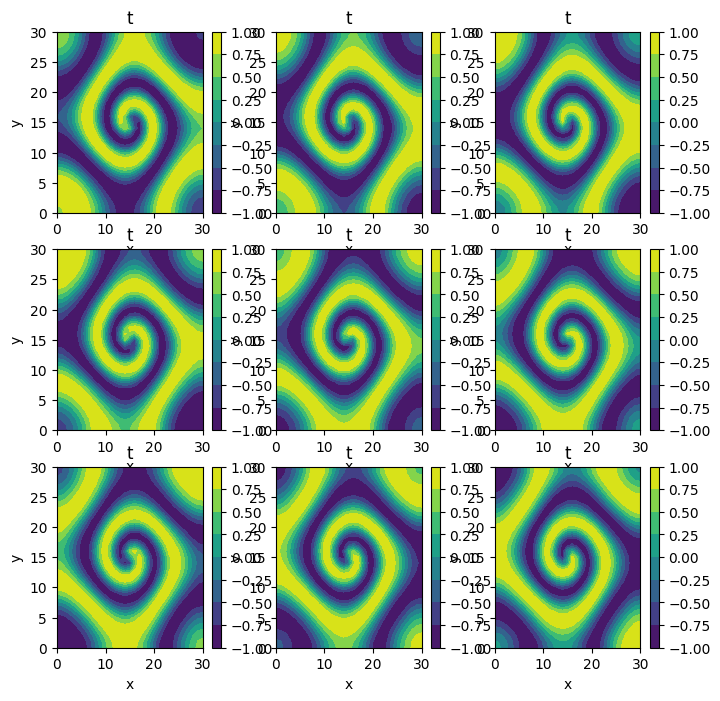

In [3]:
fig, axa = plt.subplots(3, 3, figsize=(8, 8))
for ax, i in zip(axa.ravel(), range(9)):
    image = (sol.y.T[i, :961].reshape(31,31))
    cp = ax.contourf(image, cmap = 'viridis')
    fig.colorbar(cp, ax = ax)
    ax.set_title('t')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.show()


In [4]:
print(A1)

[[ 24.94003847   0.99295252  32.80550386 ... -22.22413001  -8.98445504
   -6.4753501 ]
 [ 12.73268299  12.02949309  39.16999947 ... -15.02139101  -4.82476629
   15.86720969]
 [ -1.38095598  24.70184895  38.79066457 ...  -3.38551438  -0.75921268
   37.73898369]
 ...
 [-64.02389647  29.22746661 -43.73006064 ...  42.60088811  32.2969229
   37.9440317 ]
 [-67.76356741   8.40670057 -63.43595573 ...  30.98002141  40.47054789
    8.26766066]
 [-61.18058974 -18.5268817  -70.7356071  ...   8.04758007  42.95075454
  -26.92595056]]


In [5]:
print(A3)

[[ 0.70358468  0.72866166  0.79744529 ...  0.60339126  0.68487385
   0.71061143]
 [ 0.2767684   0.31041693  0.40890462 ...  0.90153377  0.94655769
   0.96093666]
 [-0.21781046 -0.17996952 -0.06803861 ...  0.98493196  0.97895574
   0.97599109]
 ...
 [-0.79682506 -0.81695295 -0.87303039 ... -0.45234802 -0.56606166
  -0.60421009]
 [-0.40960603 -0.44642106 -0.55249147 ... -0.81238663 -0.88765564
  -0.91226252]
 [ 0.07789884  0.03270835 -0.09952284 ... -0.97660577 -0.99274898
  -0.99696127]]


In [6]:

L = 20 # Length of Spatial Domain
n = 64 # Number of internal points
tspan = [0, 4]
dt = 0.5
t_eval = np.arange(tspan[0], tspan[1] + dt, dt)
B = 1
D1 = D2 = 0.1
m = 1 # Number of spirals

# Set Spatial Mesh Grid
x = np.linspace(-L/2, L/2, n+1)[0:-1]
y = x.copy()
X, Y = np.meshgrid(x, y)

# Set Spectral Mesh Grid
#kx = 2*np.pi*np.fft.fftfreq(n, d=L/n)
r1=np.arange(0,n/2,1)
r2=np.arange(-n/2,0,1)
kx = (2*np.pi/L)*np.concatenate((r1,r2))
